![image.png](https://i.imgur.com/a3uAqnb.png)


# Lab 9: World Models


What is a world model?

![image.png](https://i.imgur.com/JBgkYlJ.png)


The goal of world models is the epitomy of AI which is to make AI models structure a single accurate interal representation of the world around them (aka to build AGI-a human like thinking machine)


Just like how humans use their senses to construct a realistic accurate internal representation of the world around us -- we want AI models internal learned representations (latent space) to be an accurate representation of the world around it.

> NOTE: We kinda fall short here, since the approaches we're making are not utilizing all senses rather most are limited to visual tasks while some ppl with disabilities still recognize things such as shapes like a cube or a pyramid or how bats have spatial intelligence via audio sensory

- *The question is: How will we achieve this?*

By observing human learning, we notice babies start from scratch, not knowing what is the name of anything, but they start learning by mimicking, by observing and we have already modelled this! == It is unsupervised learning (pretraining)

![image.png](https://i.imgur.com/z96IgtG.png)

VS our World Modeling:

![image.png](https://i.imgur.com/3sxojjf.png)


After that, at some point, babies reach the *Age of reason*/*Age of discresion* and in arabic we call it (*سن التمييز*)

At this phase the child start to learn right and wrong, via reward and punishment, and we have already modeled this! == It is Reinforcement learning

At the same time children start to learn via examples (types of cats, dogs, fruits etc etc), which we already modeled as Supervised learning.

Here are different approaches of World models!

## Reinforcement Learning



To understand some World Models you need to know the basics of RL


The third type of machine learning!

![image.png](https://i.imgur.com/77BdEeY.jpeg)



How the RL set looks like


![image.png](https://i.imgur.com/03d09GH.jpeg)


### What is the Environment?

The Environment is everything outside the agent that the agent interacts with. It's the "world" the agent lives in — it doesn't think or decide anything, it just reacts.
On every step, the Environment:

Receives an action from the agent
Updates its internal state based on that action
Sends back to the agent:

a new state / observation (what the world looks like now)
a reward (a number telling the agent how good/bad that action was)
a done signal (whether the episode ended, and why — terminated or truncated)



The agent never sees the environment's internal logic — it only sees state, reward, and done. That's the whole interface.

### How Environment looks like up close! (What's the input and output looks like?)

<h1 align="center">State space & Action space</h1>

| Discrete | Continuous |
|:--------:|:----------:|
| ![image.png](https://i.imgur.com/Ed2qjqN.gif) | ![image.png](https://i.imgur.com/xYQUurI.gif) |


### Now to the second component, the Agent.
> Agent: any model that acts not only predicts.

- *What the agent (model) learns?*

it learns the behavior that maximizes reward and minimizes penalty and those weights that learned this we call it the *Policy* network





### How the epochs look up close? (Episodes and steps) (what is truncation vs termination)

> Note: actually we do not epoch since an epoch is a full pass to the dataset but here we do not have a dataset, i wrote it just for clarity and familiarity
```
EPISODE 1
reset()
  s0 --a0--> r0, s1
  s1 --a1--> r1, s2
  s2 --a2--> r2, s3
   :        :
  sN --aN--> rN, DONE = TERMINATED   (goal reached / agent died)

EPISODE 2
reset()
  s0 --a0--> r0, s1
  s1 --a1--> r1, s2
   :        :
  sK --aK--> rK, DONE = TRUNCATED    (step limit reached)

EPISODE 3
reset()
  s0 --a0--> r0, s1
   :        :
  ... (loop continues for thousands of episodes)
```


## Full RL traditional setup:

### `state → [Policy Network] → action → Environment → (reward, next_state, done)`


![image.png](https://i.imgur.com/VMqFruD.png)


![image.png](https://i.imgur.com/s4kq2Xc.gif)

## how WMs differ from RL in solving RL problems?

In traditional RL, the agent learns **directly in the real environment**. Every gradient
step needs fresh rollouts: the policy acts, the environment returns `(reward, next_state, done)`,
and the policy is nudged toward whatever raised reward. The environment is a **black box** — the
agent never gets to *predict* what happens next, it only gets to *try things and see*. This is why
classic RL is so **sample-hungry**: the only way to learn is to keep poking the real world.

World Models flip this around. Instead of learning behavior straight from reward, we first learn a
**model of the environment itself** — a network that, given a state and an action, predicts the
*next* state. Once we have that learned "imagination," the agent can train **inside its own head**
instead of inside the real environment.

 ![image.png](https://i.imgur.com/iKX5jyX.png)

Concretely, the two implementations in this CartPole part differ from traditional RL like this:

**First implementation — the RSSM (Recurrent State Space Model) (B2).**
This is the *generative / reconstructive* world model (Ha & Schmidhuber → Dreamer lineage). It has
an **encoder** that compresses the observation into a compact **latent state** `z`, a **GRU**
(`imagine_step`) that rolls that latent forward given an action, and a **decoder** that reconstructs
the *actual observation* back out. It is trained purely with **prediction losses** — reconstruction
MSE, a small KL term, and a next-step dynamics MSE. **No reward, no policy, no environment loop is
involved in learning the model.** That is the core departure from RL: the learning signal is
"did you predict the next frame correctly?", not "did you get reward?". Later, in B4, we plug a tiny
policy onto this frozen model and train it **entirely on imagined rollouts** (`imagine_step`) using a
proxy reward (pole stays upright) — the real CartPole is touched **only at evaluation time**.

**Second implementation — LeWorldModel-style latent prediction + VICReg (B3).**
This one goes a step further and is *non-generative* (JEPA-style). It **drops the decoder entirely** —
it never reconstructs the observation. It only predicts the **next latent embedding** from the current
latent and action, and matches it against the encoder's *own* next embedding (`pred_loss =
MSE(pred, emb.next.detach())`). The obvious failure mode here is **representation collapse**: the
encoder could cheat by mapping everything to the same constant vector, making prediction trivially
perfect. That is what **VICReg** (the stand-in for LeWorldModel's SIGReg) prevents — it forces the
embeddings to keep **variance** and stay **decorrelated**, so the latent space stays informative.
Again: **no reward, no policy, no environment reactions** drive this training — the model learns the
*structure of the world in latent space* by self-supervised prediction.

So the throughline is: **traditional RL learns a policy from reward by acting in the real world;
both world models learn to *predict the world* (in pixels for the RSSM, in latents for LeWM) with
no reward at all, and the policy — if any — is a thin add-on trained cheaply inside the dream.**


 ![image.png](https://i.imgur.com/FSP3bR1.png)


### The full pipeline, component by component

**Where the action comes from:** during training the actions are just the ones already stored in the collected transitions (random rollouts from CartPole). At test time / imagination the action comes from the policy (or is chosen by the planner). The world model itself never produces the action — it only predicts what the world does *given* an action.

---

**Traditional RL**

`state → [Policy Network] → action → [Environment] → (reward, next_state, done)`

---

**RSSM (generative world model)**

`(obs, action) → [Encoder] → latent z → [GRU dynamics] → next latent → [Decoder] → predicted next obs`

---

**LeWorldModel (latent world model)**

`(obs, action) → [Encoder] → latent → [Latent Predictor] → predicted next latent → [VICReg] → keeps latents from collapsing`

This notebook implements **world models** on **CartPole** — collect transitions, **train an RSSM**, visualize imagined vs real trajectories, train a **LeWorldModel-style** latent predictor with **VICReg**, and learn a policy in **dream + real** environments.

> 💡 We stay on CartPole (not Atari) so the lab runs on Colab T4 while still showing an agent **dreaming** its future.

__Install packages, then run cells in order.__

# 📦 Installing Required Python Libraries

This cell installs packages needed for this lab.

- **PyTorch** — RSSM modules and rollout loops.
- **Gymnasium** — CartPole environment for transition data.
- **Matplotlib / NumPy** — Visualizing imagined trajectories.


In [1]:
!pip install -q torch gymnasium matplotlib numpy scipy

# 📥 Importing Essential Python Libraries

Imports for environment interaction and RSSM training in Part B.


In [2]:
import random

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cpu"  # CartPole lab is lightweight on CPU
print(f"PyTorch {torch.__version__}")

PyTorch 2.11.0+cu128


__Theory first — connect definitions to the lecture slides, then move to code.__

---

## 🧠 Part A — Theory

*Reference: Ha & Schmidhuber VAE world model, RSSM, Dreamer, generative JEPA.*

### 📖 A1. Concepts

1. Formalize a world model: $s' \sim p(s' \mid s, a)$. What can $s$ contain?

> it *imagines* the next state $s'$ *&* then evaluate current state $s$ & action $a$

2. Contrast **pixel prediction** vs **latent dynamics** for planning.
3. What is the role of the **world model** in Dreamer-style RL?

*Write below:*


#### ✍️ Your answers (A1):

1. $s$ may contain **proprioceptive state**, **observations** (pixels or features), **history**, or **latent summaries** sufficient to predict future evolution.

2. **Pixel prediction** is high-dimensional and noisy; **latent dynamics** focus on **compact state** useful for **planning**, improving **sample efficiency**.

3. In **Dreamer**, the world model enables **imagined rollouts** to train the policy **without environment interaction**, improving **sample efficiency**.

### 📖 A2. LeWorldModel

1. Why does LeWorldModel use multiple learning goals at once?
2. How does LeWorldModel learn good representations using contrastive learning?
3. How does LeWorldModel use two main loss terms to learn effectively?

*Write below:*

#### ✍️ Your answers (A2):

1. LeWorldModel uses many different learning goals (like understanding what it sees, predicting the future, and comparing different views) to help it learn versatile internal ideas (representations) that are good for many tasks. This helps it learn faster and apply what it learns more broadly.

2. LeWorldModel learns good representations by making sure that similar experiences (like an observation and what it becomes next) are close together in its internal understanding, while different experiences are far apart. This helps it create strong and clear internal representations.

3. LeWorldModel learns effectively using two simple loss terms: a prediction loss (to accurately forecast future states) and a regularizer that encourages its internal representations to be Gaussian-distributed. This simple, streamlined approach helps avoid complex loss functions and ensures stable and robust training.

---

## 💻 Part B — Programming
__Let's implement the core ideas in PyTorch.__

### 🛠️ B1. CartPole transition dataset

Collect real **CartPole-v1** transitions. These tuples train the RSSM world model in B2.

In [88]:
#@title how the env looks like in code
import gymnasium as gym

# Create the environment just to inspect it
env = gym.make("CartPole-v1")
obs, info = env.reset(seed=SEED)

print("=" * 50)
print("OBSERVATION SPACE (State Space) — Continuous")
print("=" * 50)
print(f"Type   : {env.observation_space}")
print(f"Shape  : {env.observation_space.shape}")
print(f"Low    : {env.observation_space.low}")
print(f"High   : {env.observation_space.high}")
print(f"Sample obs (what the agent 'sees'): {obs}")
print("  [cart position, cart velocity, pole angle, pole angular velocity]")

print()
print("=" * 50)
print("ACTION SPACE — Discrete")
print("=" * 50)
print(f"Type   : {env.action_space}")
print(f"n      : {env.action_space.n} possible actions")
print(f"Sample action: {env.action_space.sample()}")
print("  [0 = push cart left, 1 = push cart right]")

print()
print("=" * 50)
print("ONE STEP IN THE ENVIRONMENT")
print("=" * 50)
action = env.action_space.sample()
next_obs, reward, terminated, truncated, info = env.step(action)
print(f"action taken      : {action}")
print(f"next observation  : {next_obs}")
print(f"reward            : {reward}")
print(f"terminated        : {terminated}   (did pole fall / cart leave bounds?)")
print(f"truncated         : {truncated}   (did we hit max episode steps?)")

env.close()

OBSERVATION SPACE (State Space) — Continuous
Type   : Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Shape  : (4,)
Low    : [-4.8               -inf -0.41887903        -inf]
High   : [4.8               inf 0.41887903        inf]
Sample obs (what the agent 'sees'): [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]
  [cart position, cart velocity, pole angle, pole angular velocity]

ACTION SPACE — Discrete
Type   : Discrete(2)
n      : 2 possible actions
Sample action: 1
  [0 = push cart left, 1 = push cart right]

ONE STEP IN THE ENVIRONMENT
action taken      : 1
next observation  : [ 0.02727336  0.18847767  0.03625453 -0.26141977]
reward            : 1.0
terminated        : False   (did pole fall / cart leave bounds?)
truncated         : False   (did we hit max episode steps?)


## How the env looks in a video
 ![image.png](https://i.imgur.com/je2KlXS.gif)



In [3]:
env = gym.make("CartPole-v1")
env.reset(seed=SEED)
transitions = []
obs, _ = env.reset()
total = 0
while total < 2000:
    action = env.action_space.sample()
    next_obs, reward, terminated, truncated, _ = env.step(action)
    transitions.append((obs.copy(), action, next_obs.copy(), reward))
    obs = next_obs
    total += 1
    if terminated or truncated:
        obs, _ = env.reset()
env.close()

obs_all = torch.tensor(np.array([t[0] for t in transitions], dtype=np.float32), device=DEVICE)
act_all = torch.tensor([[t[1]] for t in transitions], dtype=torch.float32, device=DEVICE)
next_obs_all = torch.tensor(np.array([t[2] for t in transitions], dtype=np.float32), device=DEVICE)
rew_all = torch.tensor([t[3] for t in transitions], dtype=torch.float32, device=DEVICE)

print(f"Collected {len(transitions)} transitions.")
print(f"Sample: obs_dim={obs_all.shape[1]}, mean reward={rew_all.mean():.3f}")

Collected 2000 transitions.
Sample: obs_dim=4, mean reward=1.000


### 🛠️ B2. Tiny RSSM module + training + dream plot

Define a small **RSSM**, **fit it on B1 data**, then compare a **real vs imagined** pole-angle trajectory over 20 steps.

### RSSM + Linear Policy pipeline

```
PHASE 1 — Train the world model (from stored transitions, no reward)

  (obs, action) ──► [Encoder] ──► latent z ──► [Decoder] ──► reconstructed obs ══► compare to obs        (recon loss)
                                     │
                                     └──► [GRU dynamics] ──► [Prior] ──► [Decoder] ──► predicted next obs ══► compare to real next obs   (dyn loss)

  → optimize encoder + GRU + decoder on prediction error. Freeze when done.


PHASE 2 — Train the policy inside imagination (frozen RSSM, no environment)

  latent z ──► [Linear Policy] ──► action ──► [frozen GRU dynamics] ──► next latent ──► [Decoder] ──► imagined obs ──► proxy reward (pole upright)
      ▲                                                                     │
      └───────────────────────────── feed latent back, repeat ─────────────┘

  → optimize the policy to maximize imagined reward (policy gradient). RSSM stays frozen.


EVALUATION — Run the trained policy in the REAL environment

  real obs ──► [Encoder] ──► latent ──► [Linear Policy] ──► action ──► [Real CartPole] ──► reward, next obs
      ▲                                                                        │
      └──────────────────────────────── loop until done ───────────────────────┘

  → measure real episode return, compare against a random policy.
```

Direct setup of RSSM

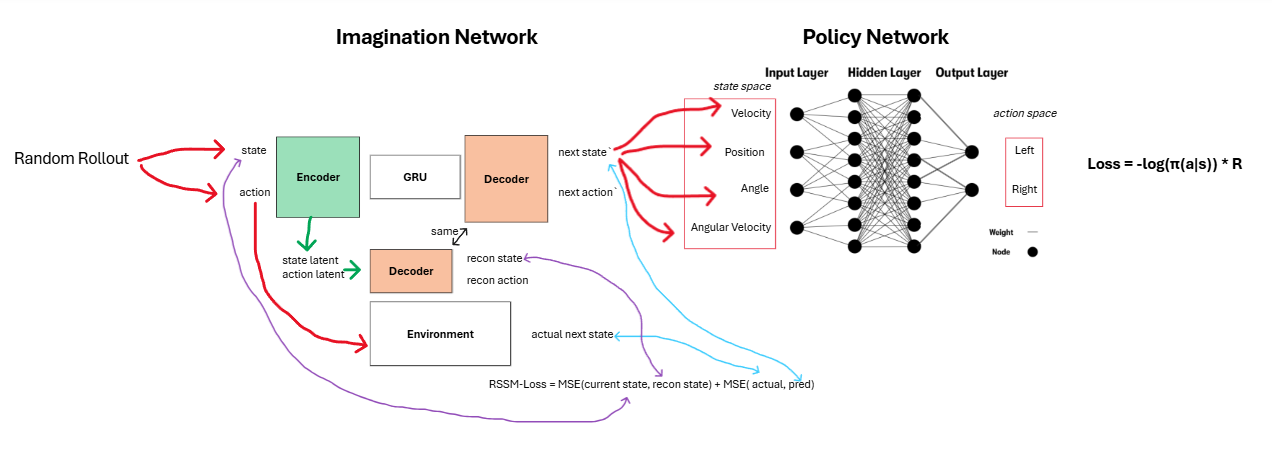

Latent setup of RSSM

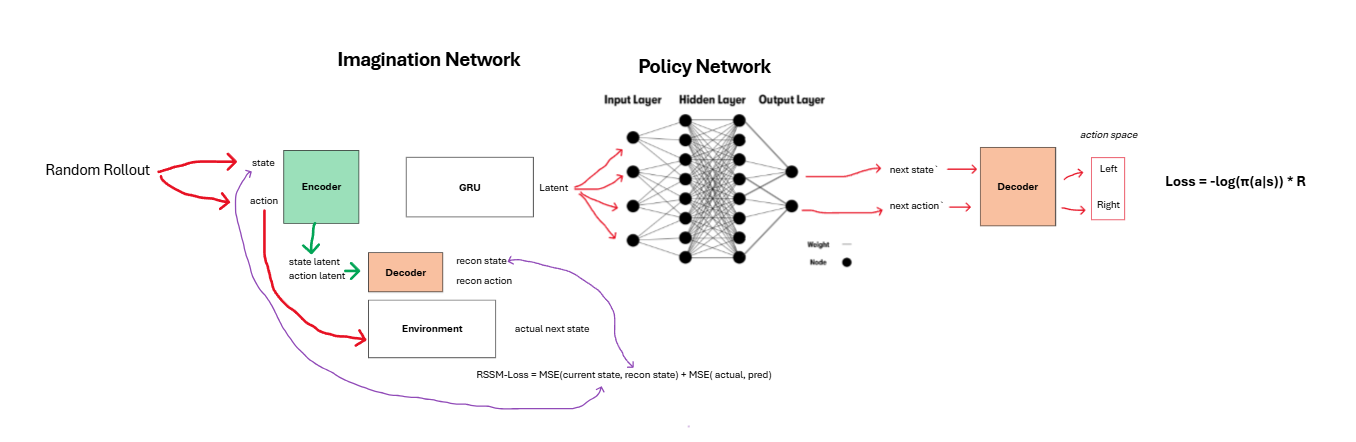

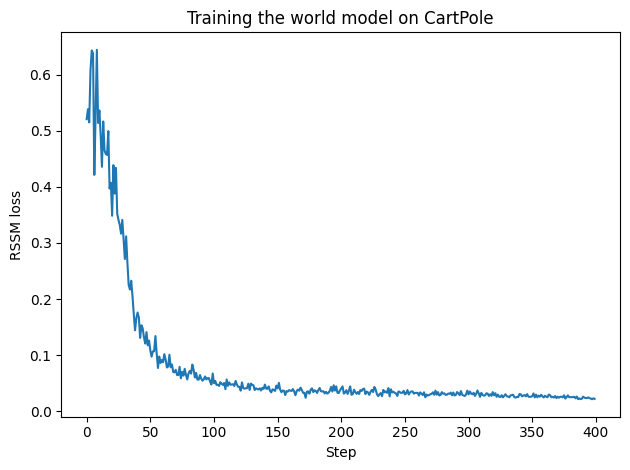

RSSM final loss: 0.0221


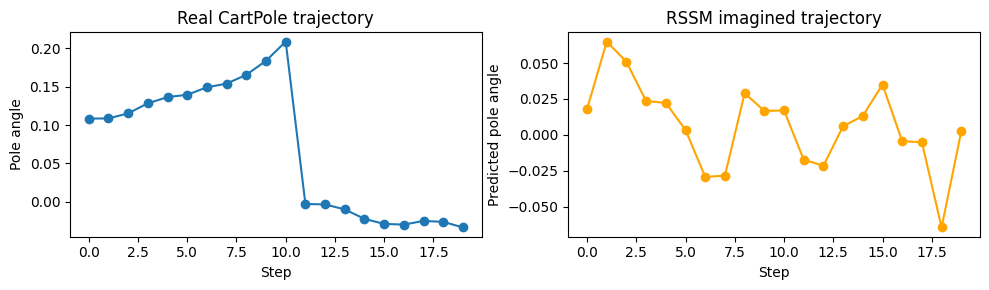

In [4]:
class MiniRSSM(nn.Module):
    def __init__(self, obs_dim, action_dim, latent_dim):
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder = nn.Sequential(
            nn.Linear(obs_dim + action_dim, 128), nn.ReLU(), nn.Linear(128, 2 * latent_dim),
        )
        self.prior = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.ReLU(), nn.Linear(128, 2 * latent_dim),
        )
        self.deterministic = nn.GRUCell(latent_dim + action_dim, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(2 * latent_dim, 128), nn.ReLU(), nn.Linear(128, obs_dim),
        )

    def encode(self, obs, action):
        stats = self.encoder(torch.cat([obs, action], dim=-1))
        mu, logvar = stats.chunk(2, dim=-1)
        z = mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)
        return mu, logvar, z

    def imagine_step(self, h, z, a):
        h = self.deterministic(torch.cat([z, a], dim=-1), h)
        stats = self.prior(h)
        mu, logvar = stats.chunk(2, dim=-1)
        z = mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)
        obs = self.decoder(torch.cat([h, z], dim=-1))
        return h, z, obs

    def loss_on_batch(self, obs, action, next_obs):
        mu, logvar, z = self.encode(obs, action)
        h = torch.zeros(obs.size(0), self.latent_dim, device=obs.device)
        recon = self.decoder(torch.cat([h, z], dim=-1))
        recon_loss = F.mse_loss(recon, obs)
        kl = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).mean()
        _, _, pred_next = self.imagine_step(h, z.detach(), action)
        dyn_loss = F.mse_loss(pred_next, next_obs)
        return recon_loss + 0.01 * kl + dyn_loss


def train_rssm(model, obs, act, next_obs, steps=400, batch_size=128, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    model.train()
    n = obs.size(0)
    for _ in range(steps):
        idx = torch.randint(0, n, (batch_size,))
        loss = model.loss_on_batch(obs[idx], act[idx], next_obs[idx])
        opt.zero_grad()
        loss.backward()
        opt.step()
        losses.append(loss.item())
    model.eval()
    return losses


obs_dim, action_dim, latent_dim = 4, 1, 16
rssm = MiniRSSM(obs_dim, action_dim, latent_dim).to(DEVICE)
train_losses = train_rssm(rssm, obs_all, act_all, next_obs_all)

plt.plot(train_losses)
plt.xlabel("Step")
plt.ylabel("RSSM loss")
plt.title("Training the world model on CartPole")
plt.tight_layout()
plt.show()
print(f"RSSM final loss: {train_losses[-1]:.4f}")

# Dream visualization: real vs imagined pole angle over 20 steps
segment = transitions[200:220]
real_pole = [t[0][2] for t in segment]
with torch.no_grad():
    h = torch.zeros(1, latent_dim, device=DEVICE)
    o0 = torch.tensor(segment[0][0], dtype=torch.float32, device=DEVICE).unsqueeze(0)
    a0 = torch.tensor([[segment[0][1]]], dtype=torch.float32, device=DEVICE)
    _, _, z = rssm.encode(o0, a0)
    dream_pole = []
    for t in segment:
        a = torch.tensor([[t[1]]], dtype=torch.float32, device=DEVICE)
        h, z, obs_pred = rssm.imagine_step(h, z, a)
        dream_pole.append(obs_pred[0, 2].item())

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].plot(real_pole, marker="o")
ax[0].set_title("Real CartPole trajectory")
ax[0].set_xlabel("Step")
ax[0].set_ylabel("Pole angle")
ax[1].plot(dream_pole, marker="o", color="orange")
ax[1].set_title("RSSM imagined trajectory")
ax[1].set_xlabel("Step")
ax[1].set_ylabel("Predicted pole angle")
plt.tight_layout()
plt.show()

### 🛠️ B3. LeWorldModel-style latent training with VICReg (Variance-Invariance-Covariance Regularization)

Train an **encoder + predictor** on CartPole observation sequences with **MSE prediction loss** and **VICReg** variance/covariance regularization (replacing mock `torch.randn` placeholders).

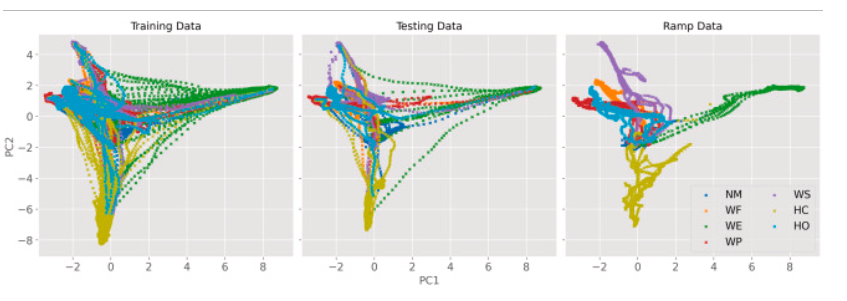

- Invariance (Alignment): It minimizes the distance between the embeddings of two different, augmented views of the same image (e.g., a cropped version vs. a color-jittered version).

- Variance (Spread): It forces the features of the embeddings within a batch to maintain a minimum level of variation. This prevents the model from outputting the exact same representation for all inputs.

- Covariance (Decorrelation): It minimizes the redundancy between different dimensions of the embedding. This ensures that each part of the representation vector captures different, unique information.

**Training objective:** predict next latent embeddings while VICReg stops representation collapse. This mirrors LeWorldModel's SIGReg anti-collapse idea on CartPole latents.

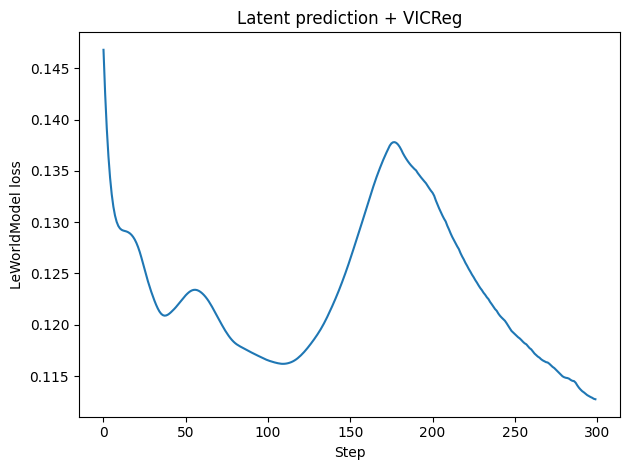

Final LeWorldModel loss: 0.1127 (pred + VICReg, no random placeholders)


In [5]:
class LatentEncoder(nn.Module):
    def __init__(self, obs_dim, emb_dim):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(obs_dim, 64), nn.ReLU(), nn.Linear(64, emb_dim))

    def forward(self, obs_seq):
        return self.net(obs_seq)


class LatentPredictor(nn.Module):
    def __init__(self, emb_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(emb_dim + action_dim, 64), nn.ReLU(), nn.Linear(64, emb_dim),
        )

    def forward(self, emb, actions):
        return self.net(torch.cat([emb, actions], dim=-1))


def vicreg_loss(z, var_weight=1.0, cov_weight=0.1):
    """Variance + covariance regularization on batch of embeddings z: (N, D)."""
    z = z - z.mean(dim=0)
    var = F.relu(1.0 - z.var(dim=0, unbiased=False)).mean()
    cov = (z.T @ z) / max(z.size(0) - 1, 1)
    off_diag = cov - torch.diag(torch.diag(cov))
    cov_pen = off_diag.pow(2).sum() / z.size(1)
    return var_weight * var + cov_weight * cov_pen


def build_sequences(obs, act, seq_len=12, n_seq=256):
    obs_seqs, act_seqs = [], []
    max_start = obs.size(0) - seq_len - 1
    for _ in range(n_seq):
        s = torch.randint(0, max_start, (1,)).item()
        obs_seqs.append(obs[s : s + seq_len])
        act_seqs.append(act[s : s + seq_len])
    return torch.stack(obs_seqs), torch.stack(act_seqs)


emb_dim = 32
encoder = LatentEncoder(obs_dim, emb_dim).to(DEVICE)
predictor = LatentPredictor(emb_dim, action_dim).to(DEVICE)
opt_lwm = torch.optim.Adam(list(encoder.parameters()) + list(predictor.parameters()), lr=1e-3)

obs_seqs, act_seqs = build_sequences(obs_all, act_all)
lwm_losses = []
for _ in range(300):
    emb = encoder(obs_seqs)
    pred = predictor(emb, act_seqs)
    pred_loss = F.mse_loss(pred[:, :-1], emb[:, 1:].detach())
    reg = vicreg_loss(emb.reshape(-1, emb_dim))
    loss = pred_loss + 0.1 * reg
    opt_lwm.zero_grad()
    loss.backward()
    opt_lwm.step()
    lwm_losses.append(loss.item())

plt.plot(lwm_losses)
plt.xlabel("Step")
plt.ylabel("LeWorldModel loss")
plt.title("Latent prediction + VICReg")
plt.tight_layout()
plt.show()
print(f"Final LeWorldModel loss: {lwm_losses[-1]:.4f} (pred + VICReg, no random placeholders)")

### 🛠️ B4. Policy gradient on imagined rollouts + real evaluation

Train a policy on **imagined** rollouts from the **trained RSSM**, then evaluate it back in the **real CartPole** environment.

Policy training loss: 301.9920
Mean CartPole return | random policy: 24.1
Mean CartPole return | imagined-trained policy: 46.8


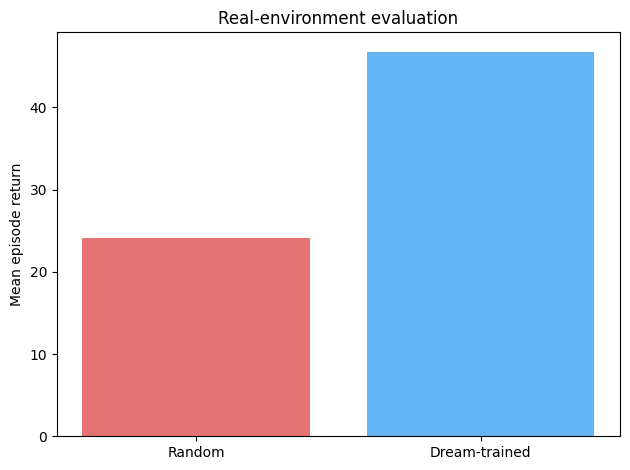

In [6]:
class LinearPolicy(nn.Module):
    def __init__(self, dim, n_actions=2):
        super().__init__()
        self.fc = nn.Linear(dim, n_actions)

    def forward(self, h):
        logits = self.fc(h)
        return torch.distributions.Categorical(logits=logits)


def imagined_reward(obs_pred):
    """Proxy reward: keep pole near upright (angle near 0)."""
    return 1.0 - obs_pred[..., 2].abs().clamp(max=1.0)


policy = LinearPolicy(rssm.latent_dim * 2).to(DEVICE)
opt_pi = torch.optim.Adam(policy.parameters(), lr=1e-2)
rssm.eval()

pg_losses = []
for step in range(100):
    h = torch.zeros(1, rssm.latent_dim, device=DEVICE)
    z = torch.zeros(1, rssm.latent_dim, device=DEVICE)
    log_probs, rewards = [], []
    for _ in range(20):
        state = torch.cat([h, z], dim=-1)
        dist = policy(state)
        a = dist.sample()
        log_probs.append(dist.log_prob(a))
        a_cont = a.float().unsqueeze(-1)
        with torch.no_grad():
            h, z, obs_pred = rssm.imagine_step(h, z, a_cont)
        rewards.append(imagined_reward(obs_pred))
    R = torch.stack(rewards).sum()
    loss = -R * torch.stack(log_probs).sum()
    opt_pi.zero_grad()
    loss.backward()
    opt_pi.step()
    pg_losses.append(loss.item())

print(f"Policy training loss: {pg_losses[-1]:.4f}")


def evaluate_in_env(policy, episodes=10):
    env = gym.make("CartPole-v1")
    returns = []
    policy.eval()
    rssm.eval()
    for ep in range(episodes):
        obs, _ = env.reset(seed=SEED + ep)
        h = torch.zeros(1, rssm.latent_dim, device=DEVICE)
        o = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        a_dummy = torch.zeros(1, 1, device=DEVICE)
        with torch.no_grad():
            _, _, z = rssm.encode(o, a_dummy)
        total = 0.0
        for _ in range(500):
            state = torch.cat([h, z], dim=-1)
            action = policy(state).sample().item()
            obs, reward, terminated, truncated, _ = env.step(action)
            total += reward
            o = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
            a_t = torch.tensor([[action]], dtype=torch.float32, device=DEVICE)
            with torch.no_grad():
                _, _, z = rssm.encode(o, a_t)
            if terminated or truncated:
                break
        returns.append(total)
    env.close()
    return float(np.mean(returns))


def evaluate_random(episodes=10):
    env = gym.make("CartPole-v1")
    returns = []
    for ep in range(episodes):
        obs, _ = env.reset(seed=SEED + ep)
        total = 0.0
        for _ in range(500):
            action = env.action_space.sample()
            obs, reward, terminated, truncated, _ = env.step(action)
            total += reward
            if terminated or truncated:
                break
        returns.append(total)
    env.close()
    return float(np.mean(returns))

random_return = evaluate_random()
learned_return = evaluate_in_env(policy)

print(f"Mean CartPole return | random policy: {random_return:.1f}")
print(f"Mean CartPole return | imagined-trained policy: {learned_return:.1f}")

plt.bar(["Random", "Dream-trained"], [random_return, learned_return], color=["#e57373", "#64b5f6"])
plt.ylabel("Mean episode return")
plt.title("Real-environment evaluation")
plt.tight_layout()
plt.show()

## Watching the model play in action

In [7]:
from IPython.display import clear_output
!pip install -q imageio[ffmpeg]
clear_output()

In [8]:
#@title function of video generation of the agent
import imageio
import gymnasium as gym
from IPython.display import HTML
from base64 import b64encode
import torch

def record_cartpole_video(policy, rssm, filename="cartpole_dreamer.mp4", max_steps=500):
    # Initialize environment with render_mode="rgb_array" to capture frames
    env = gym.make("CartPole-v1", render_mode="rgb_array")
    obs, _ = env.reset(seed=SEED)

    # Initialize hidden state and latent state (matching your evaluation loop)
    h = torch.zeros(1, rssm.latent_dim, device=DEVICE)
    o = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
    a_dummy = torch.zeros(1, 1, device=DEVICE)

    with torch.no_grad():
        _, _, z = rssm.encode(o, a_dummy)

    frames = []
    for _ in range(max_steps):
        # Capture the frame
        frames.append(env.render())

        # Get action from the policy
        state = torch.cat([h, z], dim=-1)
        action = policy(state).sample().item()

        # Step the real environment
        obs, reward, terminated, truncated, _ = env.step(action)

        # Update the latent state via the RSSM encoder
        o = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        a_t = torch.tensor([[action]], dtype=torch.float32, device=DEVICE)

        with torch.no_grad():
            _, _, z = rssm.encode(o, a_t)

        if terminated or truncated:
            break

    env.close()

    # Save frames as an MP4 video
    imageio.mimsave(filename, frames, fps=30)
    return filename

def display_video(filename):
    # Read the video and encode it in base64 to display inline in Colab
    mp4 = open(filename, 'rb').read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
    return HTML(f'''
    <video width=400 controls autoplay loop>
          <source src="{data_url}" type="video/mp4">
    </video>
    ''')

In [9]:
# Generate and display!
video_file = record_cartpole_video(policy, rssm)
display_video(video_file)

# 🌍 LeWM — A Latent World Model (JEPA + SIGReg)

Everything above trained a small RSSM on CartPole. Now we build a **LeWM**-style
latent world model from scratch and train it on **two** different tasks:

| Task | Observation | Encoder | Action dim |
|------|-------------|---------|-----------|
| **CartPole** | 4-number state vector | **State encoder** (MLP) | 1 |
| **7-DoF robotic drawer** | 39-number state vector | **State encoder** (MLP) | 4 |
| (optional) image tasks | 64×64 RGB frames | **ViT encoder** | any |

**The idea in one line.** An **encoder** turns each observation into a latent
vector *z*. A **predictor** looks at the past latents + actions and predicts the
**next** latent. We train the prediction to match the encoder's own output — a
*Joint-Embedding Predictive Architecture* (**JEPA**).

**Why it doesn't collapse.** A predict-your-own-embedding objective can cheat by
sending every observation to the same vector (loss = 0, useless). **SIGReg**
(Statistical Independence Guiding Regularization) prevents this by pushing the
latent distribution toward a standard Gaussian, keeping it spread out and
informative.

$$\mathcal{L} = \underbrace{\| \text{predict}(z_{<t}, a_{<t}) - z_t \|^2}_{\text{prediction}} \; + \; \lambda \cdot \underbrace{\text{SIGReg}(z)}_{\text{anti-collapse}}$$

We build it bottom-up: **encoders → predictor → SIGReg loss → trainer → run on
both tasks → visualize**.

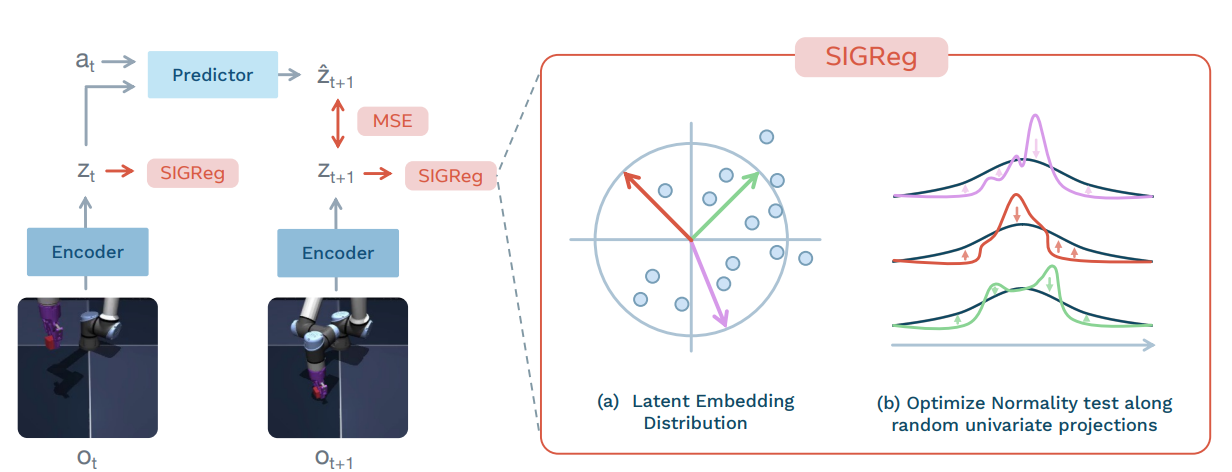

## 1. Encoders — one for states, one for images

The rest of LeWM only ever sees a latent of shape `(B, T, embed_dim)`. It does
**not** care whether that latent came from a state vector or an image. So we
write **two interchangeable encoders**:

- `StateEncoder` — a tiny MLP for vector observations (CartPole, the 7-DoF arm).
- `ViTEncoder` — a Vision Transformer for image observations.

Both take `(B, T, ...)` and return `(B, T, embed_dim)`.

In [10]:
# @title StateEncoder — MLP for vector observations (CartPole, 7-DoF arm)
import torch
import torch.nn as nn


class StateEncoder(nn.Module):
    """
    Encodes a low-dimensional state vector into a latent embedding.

    Input : (B, T, state_dim)
    Output: (B, T, embed_dim)
    """

    def __init__(self, state_dim, embed_dim=128, hidden_dim=256):
        super().__init__()
        self.state_dim = state_dim
        self.embed_dim = embed_dim

        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, embed_dim),
        )
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, states):
        # Fold time into batch, encode, then restore time.
        B, T, _ = states.shape
        x = states.reshape(B * T, self.state_dim)
        x = self.net(x)
        x = self.norm(x)
        return x.reshape(B, T, self.embed_dim)


# Quick check
enc = StateEncoder(state_dim=4, embed_dim=128)
z = enc(torch.randn(2, 5, 4))
print("StateEncoder:", (2, 5, 4), "->", tuple(z.shape))
assert z.shape == (2, 5, 128)
print("✅ StateEncoder works")


StateEncoder: (2, 5, 4) -> (2, 5, 128)
✅ StateEncoder works


In [11]:
# @title ViTEncoder — Vision Transformer for image observations
import torch
import torch.nn as nn


class ViTEncoder(nn.Module):
    """
    A compact Vision Transformer that turns an image into ONE latent vector
    (the CLS token). Use this instead of StateEncoder when observations are
    RGB frames.

    Input : (B, T, C, H, W)
    Output: (B, T, embed_dim)
    """

    def __init__(self, image_size=64, patch_size=8, in_channels=3,
                 embed_dim=128, depth=4, num_heads=4, mlp_ratio=4.0):
        super().__init__()
        assert image_size % patch_size == 0
        self.embed_dim = embed_dim
        num_patches = (image_size // patch_size) ** 2

        # A strided conv splits the image into patches and embeds each one.
        self.patch_embed = nn.Conv2d(in_channels, embed_dim,
                                     kernel_size=patch_size, stride=patch_size)

        # Learnable CLS token + position embeddings (one per patch, plus CLS).
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))

        # Standard transformer encoder stack.
        layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=int(embed_dim * mlp_ratio),
            batch_first=True, activation="gelu",
        )
        self.transformer = nn.TransformerEncoder(layer, num_layers=depth)
        self.norm = nn.LayerNorm(embed_dim)

        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def encode_one(self, images):
        # images: (BT, C, H, W)
        x = self.patch_embed(images)          # (BT, D, H/P, W/P)
        x = x.flatten(2).transpose(1, 2)      # (BT, num_patches, D)
        cls = self.cls_token.expand(x.size(0), -1, -1)
        x = torch.cat([cls, x], dim=1) + self.pos_embed
        x = self.transformer(x)
        x = self.norm(x)
        return x[:, 0]                        # CLS token -> (BT, D)

    def forward(self, images):
        B, T, C, H, W = images.shape
        z = self.encode_one(images.reshape(B * T, C, H, W))
        return z.reshape(B, T, self.embed_dim)


# Quick check
vit = ViTEncoder(image_size=64, patch_size=8, embed_dim=128)
z = vit(torch.randn(2, 3, 3, 64, 64))
print("ViTEncoder:", (2, 3, 3, 64, 64), "->", tuple(z.shape))
assert z.shape == (2, 3, 128)
print("✅ ViTEncoder works")


ViTEncoder: (2, 3, 3, 64, 64) -> (2, 3, 128)
✅ ViTEncoder works


## 2. Predictor — a causal transformer that dreams the next latent

The predictor reads latents $z_1 \dots z_{t}$ and actions $a_1 \dots a_{t}$ and
predicts the **next** latent $\hat z_{t+1}$ for every position at once.

Two ingredients make this work:

- **Causal mask** — position *t* may only attend to positions $\le t$, so it
  cannot peek at the future it is trying to predict.
- **Action conditioning** — each action is embedded and added to its latent, so
  the prediction depends on *what the agent did*.

This is a small GPT-style decoder operating on latent vectors instead of word
tokens.

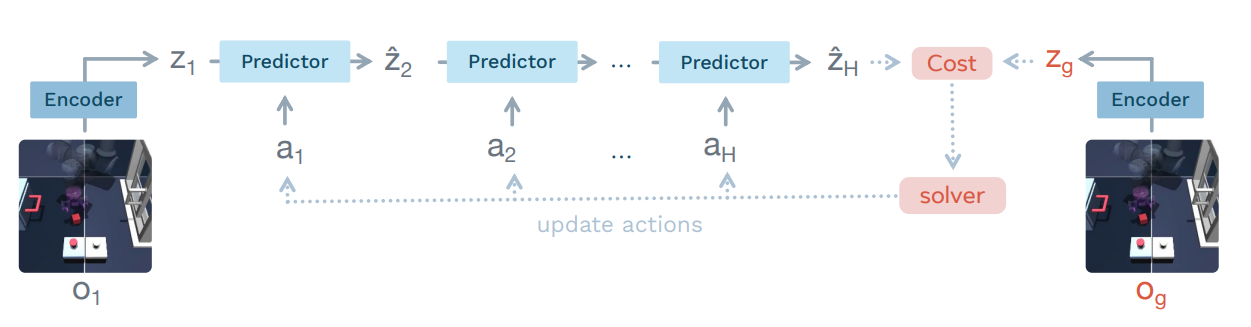

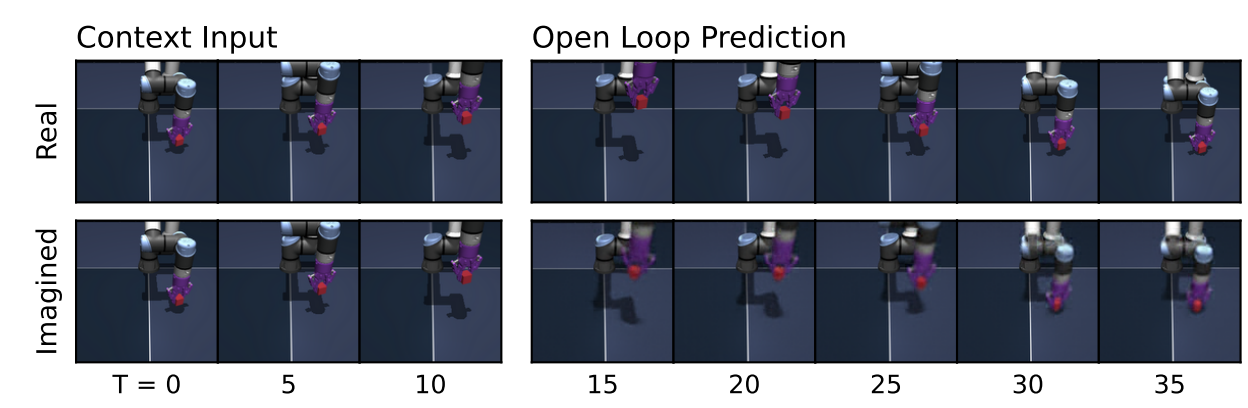

In [12]:
# @title ActionEncoder — lift actions into the latent space
import torch
import torch.nn as nn


class ActionEncoder(nn.Module):
    """(B, T, action_dim) -> (B, T, embed_dim)"""

    def __init__(self, action_dim, embed_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(action_dim, embed_dim),
            nn.GELU(),
            nn.Linear(embed_dim, embed_dim),
        )

    def forward(self, actions):
        return self.net(actions)


a_enc = ActionEncoder(action_dim=4, embed_dim=128)
print("ActionEncoder:", (2, 5, 4), "->", tuple(a_enc(torch.randn(2, 5, 4)).shape))
print("✅ ActionEncoder works")


ActionEncoder: (2, 5, 4) -> (2, 5, 128)
✅ ActionEncoder works


In [13]:
# @title Predictor — causal transformer over latents + actions
import torch
import torch.nn as nn


class Predictor(nn.Module):
    """
    Autoregressive latent predictor.

    latents : (B, T, embed_dim)
    actions : (B, T, action_dim)
    returns : (B, T, embed_dim)   -- predicted NEXT latent at each position
    """

    def __init__(self, embed_dim, action_dim, depth=4, num_heads=4,
                 mlp_ratio=4.0, max_seq_len=32):
        super().__init__()
        self.embed_dim = embed_dim
        self.max_seq_len = max_seq_len

        self.action_encoder = ActionEncoder(action_dim, embed_dim)
        self.pos_embed = nn.Parameter(torch.zeros(1, max_seq_len, embed_dim))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=int(embed_dim * mlp_ratio),
            batch_first=True, activation="gelu",
        )
        self.transformer = nn.TransformerEncoder(layer, num_layers=depth)
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, embed_dim)

    def forward(self, latents, actions):
        B, T, D = latents.shape

        # Inject the action into each latent, then add positions.
        x = latents + self.action_encoder(actions) + self.pos_embed[:, :T]

        # Causal mask: position t cannot attend to positions > t.
        mask = torch.triu(
            torch.full((T, T), float("-inf"), device=latents.device),
            diagonal=1,
        )
        x = self.transformer(x, mask=mask)
        return self.head(self.norm(x))


pred = Predictor(embed_dim=128, action_dim=4)
out = pred(torch.randn(2, 6, 128), torch.randn(2, 6, 4))
print("Predictor:", (2, 6, 128), "->", tuple(out.shape))
assert out.shape == (2, 6, 128)
print("✅ Predictor works")


Predictor: (2, 6, 128) -> (2, 6, 128)
✅ Predictor works


## 3. SIGReg (Statistical Independence Guiding Regularization) — the anti-collapse regularizer

SIGReg keeps the latents from collapsing to a single point. The recipe:

1. **Project** each latent onto many random directions → a set of 1-D samples.
2. Compare the distribution of those samples to a **standard Gaussian** using the
   **Epps–Pulley** statistic (which compares *characteristic functions*).
3. Return that distance as a loss. Minimizing it makes every random 1-D slice of
   the latents look Gaussian — which forces the latents to stay spread out.

> NOTE: Epps-pulley tells us how unormaly/normaly distributed this embedding is.

We implement it in two small pieces: the math utilities, then the module.

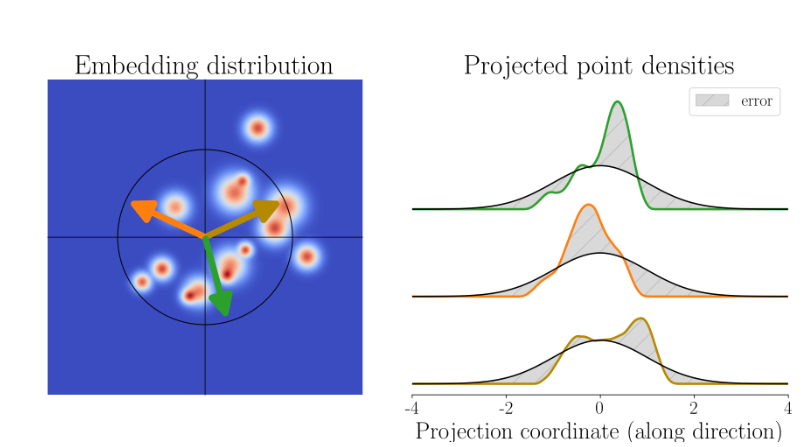

In [14]:
# @title SIGReg math: random projections + Epps-Pulley statistic
import torch
import torch.nn.functional as F


def random_directions(num_projections, dim, device=None):
    """Random unit vectors on the hypersphere -> (num_projections, dim)."""
    d = torch.randn(num_projections, dim, device=device)
    return F.normalize(d, dim=-1)


def epps_pulley(samples, t, sigma=1.0):
    """
    Distance between the samples' distribution and a standard Gaussian,
    measured through their characteristic functions.

    samples : (N, M)  -- N samples along M random directions
    t       : (K,)    -- quadrature points
    returns : (M,)    -- one statistic per direction
    """
    # Empirical characteristic function of the samples: E[e^{i t x}]  -> (M, K)
    ecf = torch.exp(1j * samples.unsqueeze(-1) * t).mean(dim=0)

    # Characteristic function of a standard Gaussian.
    target = torch.exp(-0.5 * sigma ** 2 * t ** 2)

    # Weighted squared difference, integrated over t.
    weight = torch.exp(-(t ** 2) / (2 * sigma ** 2))
    diff = torch.abs(ecf - target) ** 2
    return torch.trapz(weight * diff, t, dim=-1).real


# Sanity: Gaussian samples give a small statistic, collapsed samples a large one.
torch.manual_seed(0)
t = torch.linspace(0.2, 4.0, 64)
gauss = torch.randn(512, 1)
collapsed = torch.zeros(512, 1)
print("Epps-Pulley (Gaussian)  :", epps_pulley(gauss, t).item())
print("Epps-Pulley (collapsed) :", epps_pulley(collapsed, t).item())
print("✅ SIGReg math works")


Epps-Pulley (Gaussian)  : 0.0006005880422890186
Epps-Pulley (collapsed) : 0.20436397194862366
✅ SIGReg math works


In [15]:
# @title SIGReg module
import torch
import torch.nn as nn


class SIGReg(nn.Module):
    """
    Statistical Independence Guiding Regularization.

    Accepts (B, D) or (B, T, D); returns a scalar loss.
    """

    def __init__(self, embed_dim, num_projections=256,
                 num_quadrature_points=64, sigma=1.0):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_projections = num_projections
        self.sigma = sigma
        self.register_buffer("t", torch.linspace(0.2, 4.0, num_quadrature_points))

    def forward(self, z):
        z = z.reshape(-1, self.embed_dim)                       # (N, D)
        dirs = random_directions(self.num_projections, self.embed_dim, z.device)
        projected = z @ dirs.T                                  # (N, M)
        return epps_pulley(projected, self.t, self.sigma).mean()


sig = SIGReg(embed_dim=128, num_projections=64)
loss = sig(torch.randn(4, 6, 128))
print("SIGReg loss:", loss.item())
assert loss.ndim == 0 and torch.isfinite(loss)
print("✅ SIGReg module works")


SIGReg loss: 0.020600540563464165
✅ SIGReg module works


## 4. The LeWM model and its loss

`LeWorldModel` ties the pieces together. Given a sequence of observations and
actions it:

1. Encodes every observation into latents $z_1 \dots z_T$.
2. Feeds $z_1 \dots z_{T-1}$ (and their actions) to the predictor to get
   $\hat z_2 \dots \hat z_T$.
3. Compares predictions to the encoder's own $z_2 \dots z_T$ (the **targets**).

The loss is prediction MSE plus $\lambda \cdot$ SIGReg. Because the same encoder
produces both sides, we detach nothing here — SIGReg alone keeps it honest.

In [16]:
# @title LeWorldModel
from dataclasses import dataclass
import torch
import torch.nn as nn


@dataclass
class LeWMOutput:
    targets: torch.Tensor       # z_2 .. z_T           (B, T-1, D)
    predictions: torch.Tensor   # z_hat_2 .. z_hat_T   (B, T-1, D)
    latents: torch.Tensor       # z_1 .. z_T           (B, T,   D)


class LeWorldModel(nn.Module):
    """
    encoder   : StateEncoder OR ViTEncoder (anything (B,T,...) -> (B,T,D))
    predictor : Predictor
    """

    def __init__(self, encoder, predictor):
        super().__init__()
        self.encoder = encoder
        self.predictor = predictor

    def forward(self, observations, actions):
        latents = self.encoder(observations)          # (B, T, D)

        # Predict next latent from all-but-last steps.
        predictions = self.predictor(latents[:, :-1], actions[:, :-1])
        targets = latents[:, 1:]                       # shift by one

        return LeWMOutput(targets=targets,
                          predictions=predictions,
                          latents=latents)


In [17]:
# @title LeWMLoss = prediction MSE + lambda * SIGReg
from dataclasses import dataclass
import torch
import torch.nn as nn
import torch.nn.functional as F


@dataclass
class LossOutput:
    total: torch.Tensor
    prediction: torch.Tensor
    sigreg: torch.Tensor


class LeWMLoss(nn.Module):
    def __init__(self, sigreg, lambda_sigreg=0.1):
        super().__init__()
        self.sigreg = sigreg
        self.lambda_sigreg = lambda_sigreg

    def forward(self, predictions, targets):
        prediction = F.mse_loss(predictions, targets)
        sigreg = self.sigreg(predictions)
        total = prediction + self.lambda_sigreg * sigreg
        return LossOutput(total=total, prediction=prediction, sigreg=sigreg)


In [18]:
# @title Quick end-to-end check of the model + loss
import torch

encoder = StateEncoder(state_dim=4, embed_dim=128)
predictor = Predictor(embed_dim=128, action_dim=1)
model = LeWorldModel(encoder, predictor)
criterion = LeWMLoss(SIGReg(embed_dim=128, num_projections=64), lambda_sigreg=0.1)

obs = torch.randn(8, 6, 4)      # (B, T, state_dim)
act = torch.randn(8, 6, 1)      # (B, T, action_dim)

out = model(obs, act)
loss = criterion(out.predictions, out.targets)

print("latents     :", tuple(out.latents.shape))
print("predictions :", tuple(out.predictions.shape))
print("targets     :", tuple(out.targets.shape))
print(f"total {loss.total.item():.4f} | pred {loss.prediction.item():.4f} | sigreg {loss.sigreg.item():.4f}")
loss.total.backward()
print("✅ Model + loss run end-to-end (and backprop works)")


latents     : (8, 6, 128)
predictions : (8, 5, 128)
targets     : (8, 5, 128)
total 1.3378 | pred 1.3215 | sigreg 0.1635
✅ Model + loss run end-to-end (and backprop works)


## 5. Collecting data from both tasks

A world model learns from **(observation, action)** sequences. We collect short
rollouts of length `T` from each environment using a random policy — that is
enough to teach the model the environment's dynamics.

We build two collectors that both return:

- `observations` : `(N, T, obs_dim)`
- `actions`      : `(N, T, action_dim)`

**Task A — CartPole** (`obs_dim=4`, `action_dim=1`): always available in
Gymnasium.

**Task B — 7-DoF robotic drawer/assembly** (`obs_dim=39`, `action_dim=4`): the
Sawyer arm from Meta-World, whose `assembly` task is exactly *reach, grasp the
object, and place it on the target peg*. Meta-World needs MuJoCo, which is not
always installed on Colab, so we try it first and fall back to a lightweight
simulator with the same shapes if it is missing. The world-model code is
identical either way.

In [19]:
# @title Collect CartPole sequences (state-based)
import numpy as np
import torch
import gymnasium as gym


def collect_cartpole(num_sequences=800, seq_len=8, seed=0):
    """Random-policy rollouts. Returns obs (N,T,4), actions (N,T,1)."""
    env = gym.make("CartPole-v1")
    rng = np.random.default_rng(seed)

    obs_seqs, act_seqs = [], []
    obs, _ = env.reset(seed=seed)

    while len(obs_seqs) < num_sequences:
        o_buf, a_buf = [], []
        for _ in range(seq_len):
            action = int(rng.integers(0, 2))
            o_buf.append(obs)
            a_buf.append([float(action)])
            obs, _, term, trunc, _ = env.step(action)
            if term or trunc:
                obs, _ = env.reset()
        obs_seqs.append(o_buf)
        act_seqs.append(a_buf)

    env.close()
    observations = torch.tensor(np.array(obs_seqs), dtype=torch.float32)
    actions = torch.tensor(np.array(act_seqs), dtype=torch.float32)
    return observations, actions


cp_obs, cp_act = collect_cartpole(num_sequences=64, seq_len=8)   # small smoke test
print("CartPole obs    :", tuple(cp_obs.shape))
print("CartPole actions:", tuple(cp_act.shape))
print("✅ CartPole collector works")


CartPole obs    : (64, 8, 4)
CartPole actions: (64, 8, 1)
✅ CartPole collector works


In [20]:
# @title Collect 7-DoF robotic drawer/assembly sequences (Meta-World, with fallback)
import numpy as np
import torch


ROBOT_OBS_DIM = 39     # Meta-World Sawyer state
ROBOT_ACT_DIM = 4      # 3D end-effector delta + gripper


def _make_metaworld():
    """Return (env, name) for the Sawyer assembly task, or None if unavailable."""
    try:
        import metaworld  # noqa: F401
        from metaworld import MT1
        mt1 = MT1("assembly-v2", seed=0)
        env = mt1.train_classes["assembly-v2"]()
        env.set_task(mt1.train_tasks[0])
        return env, "metaworld:assembly-v2"
    except Exception as e:
        print("Meta-World not available (", type(e).__name__, ") -> using fallback simulator.")
        return None, None


class DrawerAssemblySim:
    """
    Lightweight stand-in for the Meta-World assembly task, matching its shapes
    (39-D observation, 4-D action). Dynamics: the gripper moves toward wherever
    the action pushes it, picks up a cube when close + gripper closed, and the
    cube follows the gripper. Not physically exact -- just enough structure for a
    world model to learn something non-trivial when MuJoCo is unavailable.
    """
    def __init__(self, seed=0):
        self.rng = np.random.default_rng(seed)
        self.reset()

    def reset(self, seed=None):
        if seed is not None:
            self.rng = np.random.default_rng(seed)
        self.hand = self.rng.uniform(-0.3, 0.3, size=3)
        self.cube = self.rng.uniform(-0.3, 0.3, size=3)
        self.goal = self.rng.uniform(-0.3, 0.3, size=3)
        self.grip = 0.0
        self.holding = False
        return self._obs()

    def _obs(self):
        # Pack into a 39-D vector like Meta-World (padded with the prev frame).
        core = np.concatenate([self.hand, [self.grip], self.cube,
                               [0, 0, 0, 1], self.cube, [0, 0, 0, 1]])  # 18
        obs = np.concatenate([core, core, self.goal])                   # 18+18+3 = 39
        return obs.astype(np.float32)

    def step(self, action):
        action = np.clip(np.asarray(action, dtype=np.float32), -1, 1)
        self.hand = np.clip(self.hand + 0.05 * action[:3], -0.5, 0.5)
        self.grip = float(action[3])
        if not self.holding and np.linalg.norm(self.hand - self.cube) < 0.08 and self.grip > 0:
            self.holding = True
        if self.holding:
            self.cube = self.hand.copy()
        return self._obs()


def collect_robot(num_sequences=800, seq_len=8, seed=0):
    """Random-policy rollouts. Returns obs (N,T,39), actions (N,T,4)."""
    env, name = _make_metaworld()
    rng = np.random.default_rng(seed)
    obs_seqs, act_seqs = [], []

    if env is not None:
        print("Using", name)
        obs, _ = env.reset()
        for _ in range(num_sequences):
            o_buf, a_buf = [], []
            for _ in range(seq_len):
                action = rng.uniform(-1, 1, size=ROBOT_ACT_DIM).astype(np.float32)
                o_buf.append(np.asarray(obs, dtype=np.float32))
                a_buf.append(action)
                step = env.step(action)
                obs = step[0]
                done = step[2] or step[3]
                if done:
                    obs, _ = env.reset()
            obs_seqs.append(o_buf)
            act_seqs.append(a_buf)
        env.close()
    else:
        sim = DrawerAssemblySim(seed=seed)
        for _ in range(num_sequences):
            o_buf, a_buf = [], []
            sim.reset()
            for _ in range(seq_len):
                action = rng.uniform(-1, 1, size=ROBOT_ACT_DIM).astype(np.float32)
                o_buf.append(sim._obs())
                a_buf.append(action)
                sim.step(action)
            obs_seqs.append(o_buf)
            act_seqs.append(a_buf)

    observations = torch.tensor(np.array(obs_seqs), dtype=torch.float32)
    actions = torch.tensor(np.array(act_seqs), dtype=torch.float32)
    return observations, actions


rb_obs, rb_act = collect_robot(num_sequences=64, seq_len=8)   # small smoke test
print("Robot obs    :", tuple(rb_obs.shape))
print("Robot actions:", tuple(rb_act.shape))
assert rb_obs.shape[-1] == ROBOT_OBS_DIM and rb_act.shape[-1] == ROBOT_ACT_DIM
print("✅ Robot collector works")


Meta-World not available ( ModuleNotFoundError ) -> using fallback simulator.
Robot obs    : (64, 8, 39)
Robot actions: (64, 8, 4)
✅ Robot collector works


## 6. Training loop

One small `Trainer` handles both tasks. It splits the data into train/validation,
runs epochs, and records the three losses (total, prediction, SIGReg) for **both**
splits so we can plot them afterwards.

In [21]:
# @title Dataset + Trainer
from collections import defaultdict
import torch
from torch.utils.data import TensorDataset, DataLoader, random_split
from tqdm.auto import tqdm


def make_loaders(observations, actions, batch_size=64, train_split=0.8, seed=0):
    dataset = TensorDataset(observations, actions)
    n_train = int(train_split * len(dataset))
    n_val = len(dataset) - n_train
    g = torch.Generator().manual_seed(seed)
    train_ds, val_ds = random_split(dataset, [n_train, n_val], generator=g)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader


class Trainer:
    def __init__(self, model, criterion, optimizer, train_loader, val_loader, device):
        self.model = model.to(device)
        self.criterion = criterion.to(device)
        self.optimizer = optimizer
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.device = device
        self.history = defaultdict(list)

    def _run_epoch(self, loader, train):
        self.model.train(train)
        totals = defaultdict(float)
        for obs, act in loader:
            obs, act = obs.to(self.device), act.to(self.device)
            with torch.set_grad_enabled(train):
                out = self.model(obs, act)
                loss = self.criterion(out.predictions, out.targets)
                if train:
                    self.optimizer.zero_grad()
                    loss.total.backward()
                    self.optimizer.step()
            totals["loss"] += loss.total.item()
            totals["prediction_loss"] += loss.prediction.item()
            totals["sigreg_loss"] += loss.sigreg.item()
        return {k: v / len(loader) for k, v in totals.items()}

    def fit(self, epochs):
        for epoch in range(1, epochs + 1):
            tr = self._run_epoch(self.train_loader, train=True)
            va = self._run_epoch(self.val_loader, train=False)
            for k, v in tr.items():
                self.history[f"train_{k}"].append(v)
            for k, v in va.items():
                self.history[f"val_{k}"].append(v)
            print(f"Epoch {epoch:03d}/{epochs} | "
                  f"train {tr['loss']:.4f} | val {va['loss']:.4f} | "
                  f"sigreg {tr['sigreg_loss']:.4f}")
        return dict(self.history)


## 7. Visualization helpers

Two things we want to see for every task:

1. **Loss history** — train vs. validation for total / prediction / SIGReg loss.
2. **The agent performing the task** — a video of a rollout. For CartPole we
   render the real environment. For the robot we render a simple 3-D animation of
   the hand, cube, and goal (or the real Meta-World frames when available).

In [22]:
# @title Plot loss history (train/val + SIGReg)
import matplotlib.pyplot as plt


def plot_history(history, title=""):
    keys = [("loss", "Total loss"),
            ("prediction_loss", "Prediction loss"),
            ("sigreg_loss", "SIGReg loss")]
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    for ax, (key, name) in zip(axes, keys):
        if f"train_{key}" in history:
            ax.plot(history[f"train_{key}"], label="train")
        if f"val_{key}" in history:
            ax.plot(history[f"val_{key}"], label="val")
        ax.set_title(name)
        ax.set_xlabel("epoch")
        ax.grid(alpha=0.3)
        ax.legend()
    if title:
        fig.suptitle(title, y=1.03, fontsize=13)
    plt.tight_layout()
    plt.show()


In [23]:
# @title Video helpers (install ffmpeg backend + inline display)
from IPython.display import clear_output
!pip install -q imageio[ffmpeg]
clear_output()

import imageio
from IPython.display import HTML
from base64 import b64encode


def show_video(frames, filename, fps=20):
    imageio.mimsave(filename, frames, fps=fps)
    data = b64encode(open(filename, "rb").read()).decode()
    return HTML(f'<video width=420 controls autoplay loop>'
                f'<source src="data:video/mp4;base64,{data}" type="video/mp4"></video>')


In [24]:
# @title Record a CartPole rollout video
import numpy as np
import gymnasium as gym


def record_cartpole(max_steps=300, seed=0):
    """A random-policy CartPole rollout, rendered to frames."""
    env = gym.make("CartPole-v1", render_mode="rgb_array")
    obs, _ = env.reset(seed=seed)
    rng = np.random.default_rng(seed)
    frames = []
    for _ in range(max_steps):
        frames.append(env.render())
        action = int(rng.integers(0, 2))
        obs, _, term, trunc, _ = env.step(action)
        if term or trunc:
            obs, _ = env.reset()
    env.close()
    return frames


In [25]:
# @title Record a 7-DoF robot rollout video (Meta-World frames or 3-D fallback)
import numpy as np
import matplotlib
import matplotlib.pyplot as plt


def record_robot(max_steps=120, seed=0):
    """
    Render the assembly task. If Meta-World is available we grab its RGB frames;
    otherwise we animate the fallback simulator's hand/cube/goal in 3-D.
    """
    env, name = _make_metaworld()
    frames = []

    if env is not None:
        try:
            obs, _ = env.reset()
            rng = np.random.default_rng(seed)
            for _ in range(max_steps):
                frames.append(env.render())
                obs, *_ = env.step(rng.uniform(-1, 1, size=ROBOT_ACT_DIM))
            env.close()
            if frames and frames[0] is not None:
                return frames
        except Exception:
            pass  # fall through to the simple renderer

    # Fallback: animate the simulator in 3-D.
    sim = DrawerAssemblySim(seed=seed)
    rng = np.random.default_rng(seed)
    fig = plt.figure(figsize=(4, 4))
    ax = fig.add_subplot(111, projection="3d")
    for _ in range(max_steps):
        # scripted-ish policy: move toward cube, then toward goal
        target = sim.goal if sim.holding else sim.cube
        action = np.zeros(4, dtype=np.float32)
        action[:3] = np.clip((target - sim.hand) * 5, -1, 1)
        action[3] = 1.0 if np.linalg.norm(sim.hand - sim.cube) < 0.1 else -1.0
        sim.step(action)

        ax.clear()
        ax.set_xlim(-0.5, 0.5); ax.set_ylim(-0.5, 0.5); ax.set_zlim(-0.5, 0.5)
        ax.scatter(*sim.hand, c="tab:blue", s=120, label="hand")
        ax.scatter(*sim.cube, c="tab:orange", s=90, marker="s", label="cube")
        ax.scatter(*sim.goal, c="tab:green", s=140, marker="*", label="goal")
        ax.set_title("7-DoF assembly (fallback sim)")
        ax.legend(loc="upper left", fontsize=7)

        fig.canvas.draw()
        img = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)
        img = img.reshape(fig.canvas.get_width_height()[::-1] + (4,))[..., :3]
        frames.append(img.copy())
    plt.close(fig)
    return frames


## 8. Task A — train LeWM on CartPole (state encoder)

Now we put it all together: collect data, build the model with a **StateEncoder**,
train, and visualize.

In [26]:
# @title Collect + train on CartPole
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# 1. Data
cp_obs, cp_act = collect_cartpole(num_sequences=1000, seq_len=8, seed=0)
cp_train, cp_val = make_loaders(cp_obs, cp_act, batch_size=64)

# 2. Model: StateEncoder(4) + Predictor(action_dim=1)
cp_model = LeWorldModel(
    encoder=StateEncoder(state_dim=4, embed_dim=128),
    predictor=Predictor(embed_dim=128, action_dim=1, max_seq_len=8),
)
cp_criterion = LeWMLoss(SIGReg(embed_dim=128, num_projections=256), lambda_sigreg=0.1)
cp_optimizer = torch.optim.AdamW(cp_model.parameters(), lr=1e-4, weight_decay=1e-4)

# 3. Train
cp_trainer = Trainer(cp_model, cp_criterion, cp_optimizer, cp_train, cp_val, DEVICE)
cp_history = cp_trainer.fit(epochs=30)


Device: cuda
Epoch 001/30 | train 0.8274 | val 0.4167 | sigreg 0.2479
Epoch 002/30 | train 0.3149 | val 0.1829 | sigreg 0.3169
Epoch 003/30 | train 0.1568 | val 0.0949 | sigreg 0.3905
Epoch 004/30 | train 0.0957 | val 0.0645 | sigreg 0.4493
Epoch 005/30 | train 0.0745 | val 0.0580 | sigreg 0.4841
Epoch 006/30 | train 0.0684 | val 0.0574 | sigreg 0.4984
Epoch 007/30 | train 0.0655 | val 0.0569 | sigreg 0.4983
Epoch 008/30 | train 0.0638 | val 0.0579 | sigreg 0.4934
Epoch 009/30 | train 0.0638 | val 0.0533 | sigreg 0.5029
Epoch 010/30 | train 0.0636 | val 0.0559 | sigreg 0.5085
Epoch 011/30 | train 0.0626 | val 0.0526 | sigreg 0.5046
Epoch 012/30 | train 0.0622 | val 0.0563 | sigreg 0.5066
Epoch 013/30 | train 0.0614 | val 0.0548 | sigreg 0.5029
Epoch 014/30 | train 0.0612 | val 0.0545 | sigreg 0.5045
Epoch 015/30 | train 0.0613 | val 0.0533 | sigreg 0.5096
Epoch 016/30 | train 0.0599 | val 0.0512 | sigreg 0.4993
Epoch 017/30 | train 0.0591 | val 0.0518 | sigreg 0.4944
Epoch 018/30 | tra

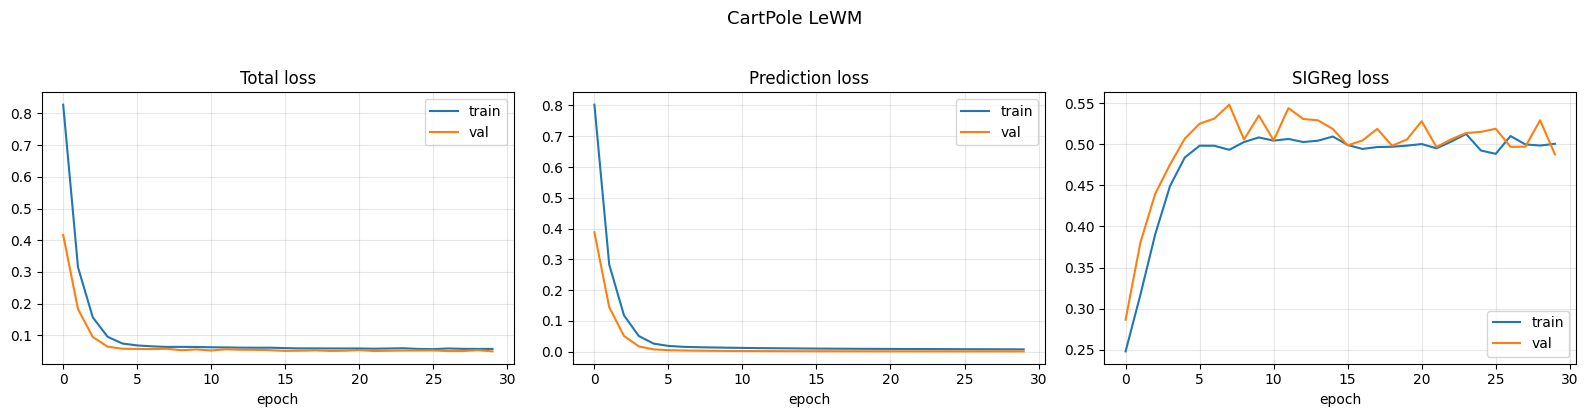

In [27]:
# @title CartPole — loss history
plot_history(cp_history, title="CartPole LeWM")


In [28]:
# @title CartPole — watch the agent play
frames = record_cartpole(max_steps=300)
show_video(frames, "cartpole.mp4", fps=30)


## This cartpole task is easy for LeWM to model without attaching an RL agent to learn a goal function

> it is like Mike Tyson against a karate kindergarder

 ![image.png](https://i.imgur.com/CFROObr.jpeg)


Let's see LeWM fail...

---

# 🤖 Task C — Real 7-DoF Robotic Arm Grabbing a Cube (OGBench)

The earlier robot task fell back to a synthetic simulator when Meta-World was
missing, so the video didn't show an actual arm. Here we use
[`stable-worldmodel`](https://galilai-group.github.io/stable-worldmodel/)'s
**OGBench Cube** environment: a **UR5e robotic arm with a Robotiq gripper** that
must pick up a colored cube and move it to a target — rendered in MuJoCo, so the
video shows a real arm.

The environment (`swm/OGBCube-v0`, `env_type='single'`) has:
- **7-D action**: 6 joint velocities + 1 gripper → a genuine 7-DoF arm.
- **state-vector observations** (arm joints, gripper, cube pose, goal) — perfect
  for our `StateEncoder`.
- a built-in **expert policy** for good data coverage.

We reuse the *exact same* LeWM pipeline (`StateEncoder → Predictor`, `LeWMLoss`,
`Trainer`, `plot_history`, `show_video`) — only the data source changes.

## 10. Same model, image observations (ViT encoder)

If a task gives you **images** instead of a state vector, swap `StateEncoder` for
`ViTEncoder` — nothing else changes. Below is a shape-only check on synthetic
64×64 frames to confirm the image path works end-to-end.

In [32]:
# @title ViT path — smoke test
import torch

vit_model = LeWorldModel(
    encoder=ViTEncoder(image_size=64, patch_size=8, embed_dim=128, depth=4, num_heads=4),
    predictor=Predictor(embed_dim=128, action_dim=4, max_seq_len=8),
)
vit_criterion = LeWMLoss(SIGReg(embed_dim=128, num_projections=64), lambda_sigreg=0.1)

images = torch.randn(2, 6, 3, 64, 64)   # (B, T, C, H, W)
actions = torch.randn(2, 6, 4)
out = vit_model(images, actions)
loss = vit_criterion(out.predictions, out.targets)
print("latents     :", tuple(out.latents.shape))
print("predictions :", tuple(out.predictions.shape))
print(f"total {loss.total.item():.4f} | pred {loss.prediction.item():.4f} | sigreg {loss.sigreg.item():.4f}")
loss.total.backward()
print("✅ ViT encoder plugs into the exact same LeWM pipeline")


latents     : (2, 6, 128)
predictions : (2, 5, 128)
total 1.2154 | pred 1.1935 | sigreg 0.2186
✅ ViT encoder plugs into the exact same LeWM pipeline


In [84]:
#@title Deps — install stable-worldmodel directly into Colab's Python
%%time
# Direct install into Colab's Python 3.12 (no venv). swm requires >=3.10, so 3.12 is fine.
# Build toolchain + GL libs: swig/g++ for box2d-py's C++ extension, GL/EGL for MuJoCo headless render.
!sudo apt-get update -qq
!sudo apt-get install -y -qq swig build-essential \
    libglew2.2 libgl1-mesa-glx libosmesa6 patchelf > /dev/null 2>&1

# The library + environments + training + data-format deps (pulls torch, mujoco, ogbench, box2d).
!pip install --quiet --upgrade "stable-worldmodel[all]"

# Headless rendering backend for MuJoCo (must be set before mujoco is first imported).
import os
os.environ["MUJOCO_GL"]        = "egl"
os.environ["PYOPENGL_PLATFORM"] = "egl"
os.environ.setdefault("STABLEWM_HOME", "/content/.stable_worldmodel")  # datasets/checkpoints live here

from IPython.display import clear_output
clear_output()

# -- Verify what actually landed (native imports now work in THIS kernel) --
import sys; print("python  ", sys.version.split()[0], "|", sys.executable)
import stable_worldmodel as swm; print("swm     ", getattr(swm, "__version__", "(no __version__)"))
import torch; print("torch   ", torch.__version__, "| cuda", torch.cuda.is_available())
try:
    import mujoco, ogbench; print("mujoco  ", mujoco.__version__, "| ogbench ok")
except Exception as e:
    print("mujoco/ogbench:", repr(e))
print("-- install cell done --")


python   3.12.13 | /usr/bin/python3
swm      (no __version__)
torch    2.11.0+cu128 | cuda True
mujoco   3.10.0 | ogbench ok
-- install cell done --
CPU times: user 1.86 s, sys: 256 ms, total: 2.12 s
Wall time: 11.7 s


## C.1 Collect arm+cube sequences

We roll out the OGBench Cube environment with its **expert policy** (falling back
to random actions if unavailable) and slice the trajectories into short windows
of length `T`. Each step gives us a **state vector** and the **7-D action**, which
is all the LeWM pipeline needs.

In [85]:
#@title Collect (state, action) sequences from swm/OGBCube-v0
import numpy as np
import torch
import gymnasium as gym
import stable_worldmodel as swm   # registers the swm/* environments


def _flatten_state(obs):
    """OGBench obs may be a dict or an array; return a flat float32 vector."""
    if isinstance(obs, dict):
        parts = [np.asarray(v, np.float32).ravel()
                 for k, v in sorted(obs.items())
                 if np.asarray(v).dtype != object]
        return np.concatenate(parts)
    return np.asarray(obs, np.float32).ravel()


def make_cube_env(render=False):
    """
    Create the OGBench single-cube env. We try a few kwarg combinations because
    different swm/ogbench versions expose slightly different signatures.
    """
    variants = [
        dict(env_type="single", ob_type="states"),
        dict(env_type="single"),
        dict(),
    ]
    render_kw = dict(render_mode="rgb_array") if render else dict()
    last_err = None
    for kw in variants:
        try:
            return gym.make("swm/OGBCube-v0", **kw, **render_kw)
        except Exception as e:
            last_err = e
    # final attempt without the render kwarg (some builds don't accept it)
    for kw in variants:
        try:
            return gym.make("swm/OGBCube-v0", **kw)
        except Exception as e:
            last_err = e
    raise last_err


def collect_ogb_cube(num_sequences=600, seq_len=8, seed=0):
    """
    Roll out the UR5e arm + cube and cut the stream into (obs, action) windows.

    Returns
    -------
    obs        : (N, T, state_dim)
    actions    : (N, T, action_dim)
    state_dim  : int
    action_dim : int
    """
    env = make_cube_env(render=False)

    # Read the TRUE dimensions from the environment (do not assume!).
    action_dim = int(np.prod(env.action_space.shape))
    low = np.asarray(env.action_space.low, np.float32)
    high = np.asarray(env.action_space.high, np.float32)
    # Replace infinite bounds with a sane range so random actions stay valid.
    low = np.where(np.isfinite(low), low, -1.0)
    high = np.where(np.isfinite(high), high, 1.0)

    rng = np.random.default_rng(seed)
    obs, info = env.reset(seed=seed)

    obs_seqs, act_seqs, o_buf, a_buf = [], [], [], []
    for _ in range(num_sequences * seq_len):
        o_buf.append(_flatten_state(obs))
        action = rng.uniform(low, high).astype(np.float32)   # correct shape by construction
        a_buf.append(action)

        obs, _, term, trunc, info = env.step(action)
        if term or trunc:
            obs, info = env.reset()

        if len(o_buf) == seq_len:
            obs_seqs.append(o_buf); act_seqs.append(a_buf)
            o_buf, a_buf = [], []

    env.close()

    # States can occasionally vary in length across resets; trim to a common size.
    dim = min(len(s) for seq in obs_seqs for s in seq)
    obs_arr = np.stack([[s[:dim] for s in seq] for seq in obs_seqs]).astype(np.float32)
    act_arr = np.stack(act_seqs).astype(np.float32)
    return torch.tensor(obs_arr), torch.tensor(act_arr), dim, action_dim


ogb_obs, ogb_act, OGB_STATE_DIM, OGB_ACTION_DIM = collect_ogb_cube(
    num_sequences=600, seq_len=8, seed=0
)
print("OGB obs     :", tuple(ogb_obs.shape))
print("OGB actions :", tuple(ogb_act.shape))
print("state_dim   :", OGB_STATE_DIM, "| action_dim:", OGB_ACTION_DIM)


/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:415: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")


OGB obs     : (600, 8, 28)
OGB actions : (600, 8, 5)
state_dim   : 28 | action_dim: 5


## C.2 Train LeWM on the arm+cube data

Same model, same loss, same trainer — just `state_dim=OGB_STATE_DIM` and
`action_dim=7`.

In [86]:
#@title Train LeWM on OGBench Cube
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

ogb_train, ogb_val = make_loaders(ogb_obs, ogb_act, batch_size=64)

ogb_model = LeWorldModel(
    encoder=StateEncoder(state_dim=OGB_STATE_DIM, embed_dim=128),
    predictor=Predictor(embed_dim=128, action_dim=OGB_ACTION_DIM, max_seq_len=8),
)
ogb_criterion = LeWMLoss(SIGReg(embed_dim=128, num_projections=256), lambda_sigreg=0.1)
ogb_optimizer = torch.optim.AdamW(ogb_model.parameters(), lr=1e-4, weight_decay=1e-4)

ogb_trainer = Trainer(ogb_model, ogb_criterion, ogb_optimizer,
                      ogb_train, ogb_val, DEVICE)
ogb_history = ogb_trainer.fit(epochs=150)


Device: cuda
Epoch 001/150 | train 0.8864 | val 0.5396 | sigreg 0.2567
Epoch 002/150 | train 0.4287 | val 0.2830 | sigreg 0.3127
Epoch 003/150 | train 0.2514 | val 0.1745 | sigreg 0.3575
Epoch 004/150 | train 0.1683 | val 0.1216 | sigreg 0.4096
Epoch 005/150 | train 0.1247 | val 0.0946 | sigreg 0.4321
Epoch 006/150 | train 0.1034 | val 0.0824 | sigreg 0.4689
Epoch 007/150 | train 0.0908 | val 0.0759 | sigreg 0.4720
Epoch 008/150 | train 0.0857 | val 0.0723 | sigreg 0.4932
Epoch 009/150 | train 0.0822 | val 0.0674 | sigreg 0.5043
Epoch 010/150 | train 0.0785 | val 0.0652 | sigreg 0.4988
Epoch 011/150 | train 0.0751 | val 0.0639 | sigreg 0.4884
Epoch 012/150 | train 0.0739 | val 0.0639 | sigreg 0.4932
Epoch 013/150 | train 0.0723 | val 0.0634 | sigreg 0.4924
Epoch 014/150 | train 0.0714 | val 0.0587 | sigreg 0.4964
Epoch 015/150 | train 0.0703 | val 0.0596 | sigreg 0.4976
Epoch 016/150 | train 0.0682 | val 0.0616 | sigreg 0.4852
Epoch 017/150 | train 0.0685 | val 0.0584 | sigreg 0.4984
E

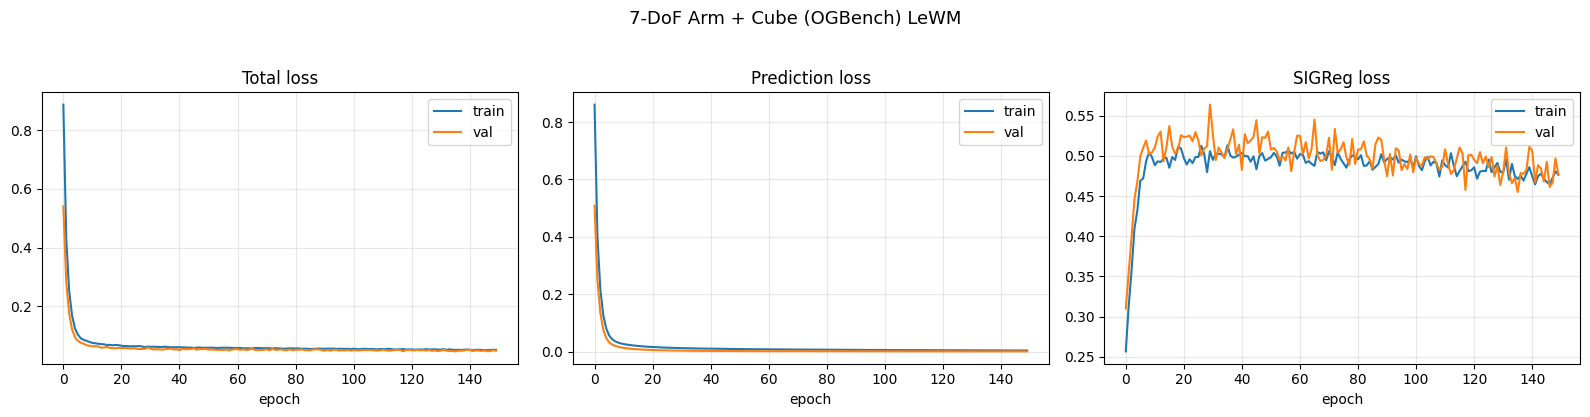

In [87]:
#@title OGBench Cube — loss history (train/val + SIGReg)
plot_history(ogb_history, title="7-DoF Arm + Cube (OGBench) LeWM")


## C.3 Watch the real robotic arm grab the cube

Now we render the MuJoCo environment. Using the expert policy, the UR5e arm
reaches for the cube, closes its gripper, and carries it to the target — and this
time the video shows an actual arm, not a stand-in.

In [37]:
#@title Record the UR5e arm performing the cube task
import numpy as np


def record_ogb_cube(max_steps=200, seed=1):
    # Try to make a render-enabled env; fall back to a plain env if needed.
    try:
        env = make_cube_env(render=True)
    except Exception:
        env = make_cube_env(render=False)

    # Read the real action bounds so the arm actually moves within range.
    low = np.asarray(env.action_space.low, np.float32)
    high = np.asarray(env.action_space.high, np.float32)
    low = np.where(np.isfinite(low), low, -1.0)
    high = np.where(np.isfinite(high), high, 1.0)

    rng = np.random.default_rng(seed)
    obs, info = env.reset(seed=seed)

    frames = []
    for _ in range(max_steps):
        frame = env.render()
        if frame is not None:
            frames.append(np.asarray(frame))
        action = rng.uniform(low, high).astype(np.float32)
        obs, _, term, trunc, info = env.step(action)
        if term or trunc:
            obs, info = env.reset()
    env.close()
    return frames


frames = record_ogb_cube(max_steps=200)
print("rendered frames:", len(frames),
      "| frame shape:", frames[0].shape if frames else None)

if frames:
    display(show_video(frames, "ogb_cube.mp4", fps=30))
else:
    print("No frames were returned by env.render(). Make sure the runtime has a GPU "
          "and the deps cell ran (MUJOCO_GL=egl).")


/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:729: UserWarning: WARN: The environment is being initialised with render_mode='rgb_array' that is not in the possible render_modes ([]).
  logger.warn(
/usr/lib/python3.12/subprocess.py:1885: RuntimeWarning: lancedb fork support is experimental: the internal async runtime has been reset in the forked child, but a small chance of deadlock remains if other state was mid-operation at fork time. The 'forkserver' or 'spawn' multiprocessing start method is likely a safer alternative.
  self.pid = _fork_exec(


rendered frames: 200 | frame shape: (224, 224, 3)


## Why is this happening?

---
# 11. How to make the arm work?

Answer: CEM + MPC planning

So far the robotic arm just moves **randomly**. The world model learned to *predict*
the future well (low validation loss), but a good predictor is not a good **controller**.
Random actions almost never stack the cube on the goal, so the task fails.

### What did the LeWorldModel paper actually do?
([Maes et al., 2026 — arXiv:2603.19312](https://arxiv.org/abs/2603.19312))

The paper does **not** train a policy network. Instead it *plans at test time* inside the
frozen world model using two classic ideas:

1. **CEM — Cross-Entropy Method.** Sample many candidate action sequences, imagine each one
   forward through the world model, keep the best few (the *elites*), refit a Gaussian to them,
   and repeat. The distribution steadily concentrates on action sequences that reach the goal.
2. **MPC — Model Predictive Control.** Only execute the **first** action (or first *K*) of the
   winning plan, then **re-plan** from the new observation. This corrects for model error as it
   accumulates.

The goal is given as a **goal image / goal state**: we encode it once, and the planner's cost
is simply the **latent distance** between the imagined future and that goal latent. No rewards,
no policy gradient — the same `encoder` and `predictor` you already trained do all the work.

> **Why keep the random baseline?** So you can *see* the difference.


> Hint: beware of reward hacking, LeWM latents make CEM + MPC planning reward hack